# DA-05. Approval Fixture와 Requested Transaction 정합성 검증

## 분석 목적

본 분석은 사전에 승인된 Approval Fixture와 실제 실행 요청인 Requested Transaction을 비교하여, 승인 조건이 외부 실행 요청 단계까지 유지되는지를 검증한다.

FPG는 거래의 승인 여부 자체를 새롭게 판단하는 시스템이 아니라, 기관 또는 사용자가 사전에 승인한 조건이 실제 외부 실행 요청에서도 그대로 준수되는지를 강제하는 Policy Enforcement Gateway이다.

따라서 본 분석의 핵심 질문은 다음과 같다.

> **사전에 승인된 Purpose, Asset, Amount, Counterparty, Destination, Period 조건과 실제 Requested Transaction이 일치하는가?**

본 Notebook에서는 각 승인 조건을 Requested Transaction과 필드 단위로 비교하고, 하나 이상의 승인 조건을 위반한 거래를 식별한다.

### 검증 범위

* Purpose 일치 여부
* Asset 일치 여부
* Amount 승인 범위 준수 여부
* Counterparty 일치 여부
* Destination 일치 여부
* 승인 유효기간 준수 여부

Execution 성공 여부, Blockchain Finality, Settlement State, Reconciliation은 본 분석의 범위에서 제외한다.

### FPG 설계 연결

Approval과 Requested Transaction이 모두 존재하더라도 두 객체가 별도로 관리되면 실제 실행 요청이 승인 범위를 벗어날 수 있다.

따라서 FPG Runtime에서는 외부 실행 직전에 다음 조건을 다시 검증해야 한다.

**Approval → Requested Transaction → Policy Match → PASS / BLOCK**

즉, 사전 승인은 실행 권한의 근거이고, 실제 Requested Transaction과의 정합성 검증은 실행 시점의 Policy Enforcement이다.


In [2]:
# 01. Ethereum Master Sample 로드 및 컬럼 확인

import pandas as pd

file_path = r"C:\Users\user\Downloads\da_master_transaction_sample_73410 - 복사본.csv"

df = pd.read_csv(file_path)

print(f"행 수 : {len(df):,}")
print(f"열 수 : {df.shape[1]:,}")

print("\n컬럼 목록:")
for col in df.columns:
    print(col)

display(df.head())

행 수 : 73,410
열 수 : 13

컬럼 목록:
block_number
block_timestamp
transaction_hash
transaction_type
from_address
to_address
value
value_lossless
gas
gas_price
receipt_status
gas_used
contract_address


,block_number,block_timestamp,transaction_hash,transaction_type,from_address,to_address,value,value_lossless,gas,gas_price,receipt_status,gas_used,contract_address
0,25921370,2026-09-06 22:43:11+00:00,0x0bcb3368369999cce62e64f92735e808789c07ce12ee...,2,0x066d4ce936db5fea75c92de48a5148fb4b826aa7,0xdac17f958d2ee523a2206206994597c13d831ec7,0.0,0,51153,71633575,1,46121,NaN
1,25921421,2026-09-06 22:53:23+00:00,0xd9fe81ef124b039c78b52d8cdf0f8bf15ef11d37624b...,4,0x59aab1bd0d26290274398c07b55955c15425e16b,0x00fe78205f5f0e63b8ad2b2ae5337f538a610e04,0.0,0,1892733,45397095,1,1270050,NaN
2,25921466,2026-09-06 23:02:23+00:00,0x395de722c86031349e6a61dc0efda07f03a31472f3ce...,2,0xd49a2cc7bf14100ad9d3e8e2d22cbedd692165c9,0xc10fc8fa761285fa3fa25aafcc10a54456ee8919,0.0,0,2888000,45720803,1,1329327,NaN
3,25921469,2026-09-06 23:02:59+00:00,0x9a3730c5f6e686676d163f9cf7b96b82f1af1fae305e...,2,0x56eddb7aa87536c09ccc2793473599fd21a8b17f,0xdac17f958d2ee523a2206206994597c13d831ec7,0.0,0,220436,1042425413,1,46109,NaN
4,25921418,2026-09-06 22:52:47+00:00,0x1243b78ddeec1c395ced21d99a8a30a1a8be2ae997de...,2,0x466ba3edd0783b0e0e675b50e7e59396b0433064,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,0.0,0,85155,1048556731,1,62248,NaN


## 데이터 구성

Ethereum Master Sample에는 실제 블록체인 Transaction과 Execution Result가 포함되어 있으나, 해당 거래에 대한 사전 Approval 정보는 존재하지 않는다.

따라서 DA-05에서는 실제 Transaction을 `Requested Transaction`의 근거로 사용하고, 이에 대응하는 `Approval Fixture`를 별도로 구성한다.

이때 Approval Fixture는 실제 금융기관의 승인 이력을 의미하지 않는다. FPG의 Approval–Request 정책 정합성 검증 로직을 평가하기 위한 통제된 검증 데이터이다.

따라서 본 Notebook의 분석 결과는 실제 시장의 승인 위반 발생률을 추정하는 데 사용하지 않으며, **승인 조건의 변경 유형별로 FPG가 Policy Violation을 식별할 수 있는지 검증하는 데 사용한다.**


In [3]:
# 02. Ethereum 실제 거래 → Requested Transaction 구성

requested_df = df[
    [
        "transaction_hash",
        "block_number",
        "block_timestamp",
        "from_address",
        "to_address",
        "value_lossless",
        "transaction_type"
    ]
].copy()

requested_df = requested_df.rename(
    columns={
        "transaction_hash": "request_id",
        "block_timestamp": "requested_at",
        "from_address": "requester_address",
        "to_address": "requested_destination",
        "value_lossless": "requested_amount"
    }
)

# Ethereum native transaction 기준 Asset 명시
requested_df["requested_asset"] = "ETH"

print(f"Requested Transaction 수: {len(requested_df):,}")

display(requested_df.head())

print("\n결측치")
display(requested_df.isna().sum().to_frame("missing"))

Requested Transaction 수: 73,410


,request_id,block_number,requested_at,requester_address,requested_destination,requested_amount,transaction_type,requested_asset
0,0x0bcb3368369999cce62e64f92735e808789c07ce12ee...,25921370,2026-09-06 22:43:11+00:00,0x066d4ce936db5fea75c92de48a5148fb4b826aa7,0xdac17f958d2ee523a2206206994597c13d831ec7,0,2,ETH
1,0xd9fe81ef124b039c78b52d8cdf0f8bf15ef11d37624b...,25921421,2026-09-06 22:53:23+00:00,0x59aab1bd0d26290274398c07b55955c15425e16b,0x00fe78205f5f0e63b8ad2b2ae5337f538a610e04,0,4,ETH
2,0x395de722c86031349e6a61dc0efda07f03a31472f3ce...,25921466,2026-09-06 23:02:23+00:00,0xd49a2cc7bf14100ad9d3e8e2d22cbedd692165c9,0xc10fc8fa761285fa3fa25aafcc10a54456ee8919,0,2,ETH
3,0x9a3730c5f6e686676d163f9cf7b96b82f1af1fae305e...,25921469,2026-09-06 23:02:59+00:00,0x56eddb7aa87536c09ccc2793473599fd21a8b17f,0xdac17f958d2ee523a2206206994597c13d831ec7,0,2,ETH
4,0x1243b78ddeec1c395ced21d99a8a30a1a8be2ae997de...,25921418,2026-09-06 22:52:47+00:00,0x466ba3edd0783b0e0e675b50e7e59396b0433064,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,0,2,ETH



결측치


,missing
request_id,0
block_number,0
requested_at,0
requester_address,0
requested_destination,46
requested_amount,0
transaction_type,0
requested_asset,0


In [4]:
# 03. requested_destination 결측 거래 확인

destination_missing = df[df["to_address"].isna()].copy()

print(f"Destination 결측 거래 수: {len(destination_missing):,}")

print("\nTransaction Type 분포")
display(
    destination_missing["transaction_type"]
    .value_counts(dropna=False)
    .to_frame("count")
)

print("\ncontract_address 존재 여부")
display(
    destination_missing["contract_address"]
    .notna()
    .value_counts()
    .rename(index={True: "존재", False: "결측"})
    .to_frame("count")
)

display(
    destination_missing[
        [
            "transaction_hash",
            "transaction_type",
            "from_address",
            "to_address",
            "value_lossless",
            "receipt_status",
            "contract_address"
        ]
    ].head(10)
)

Destination 결측 거래 수: 46

Transaction Type 분포


,count
transaction_type,
2,36
0,8
1,2



contract_address 존재 여부


,count
contract_address,
존재,46


,transaction_hash,transaction_type,from_address,to_address,value_lossless,receipt_status,contract_address
873,0x23056508ae1959e6e02578f8e3a49acb4ad1431fac97...,2,0x5ec822df1a588eff3c29e3e5042c8616fbd078d3,NaN,0,1,0x2b161edf56ba756038a53f3db776228bda0a2235
2844,0xc43b62f1625fdd8168c00bc7b63c6ceaf969dc029af7...,2,0xbcce9630c876d50004bfcd422984d1b3f9af0277,NaN,0,1,0x4906dfe553c6674edfc418b2500d0a70cbe89855
2974,0x238179143c51f017309fa9cf289d5df18b4f31360723...,2,0x2bb333d48dfaf1596d9036671d2e43168994249e,NaN,0,1,0xf8aef69201621ad20fa256da595426b7e6192dba
4677,0x874682b401b07f7f690cfd8342c46bbace63b8f76d91...,2,0x5ca162d37571a3c5a257604fccdf1399452f69aa,NaN,0,1,0x1775870d872b36169c870b45279bad67f9535e27
7251,0xb194c7287116db1856c9a700c44486afb10e6be06a4b...,2,0xdc5c4cb6f9d90ddd33d535b865c58d3a004b5cba,NaN,1100000000000000000,1,0x925905d0150787f8168f0156c06fd9797396869d
8251,0x7c579b1a55e9240133e61fcf51d31c299e5ee7c1240b...,0,0x545b7b7e9372ea6ddc805c0cdee3025eee1880b1,NaN,0,1,0xffa52d1892e16f39b1a1abcca198d383e5895e4a
10591,0x46ff9b799f63e1270d1cd67af97e9a281e4f8b6d56df...,2,0x16c0367918af1855aefa3a6d82ea3282a0725bb8,NaN,0,1,0x0bbc1a5494afc94c667f514e43f0e9401a25c492
14409,0x655fddd7b93207de00e8747150647225414320360853...,2,0x152774326ddf3819067505df9fb3f6cd2c86d021,NaN,0,1,0x8943ec551050cb213b768df35faf087c524b4f96
14608,0xc6bf73253084244d9efaa6c4ce9e0a14f0c810956c57...,1,0x249ac4978cfea9d2e87d390e28195b7fda59e388,NaN,500000000000000000,1,0x91d99bd21a0e05db1e7c44de8e56ba939932428b
15752,0x2bd9c4f8cd40d99e7bbd084110f9015cd1d78613450c...,2,0xd6d376ab6ab93391bf5802740214953d5c3c199d,NaN,3051000000000000000,1,0x36f844b88b8def9fde8c573d0e7b10a72ca9054b


In [5]:
# 04. Requested Transaction의 Destination 검증 가능 여부 구분

requested_df["request_type"] = np.where(
    requested_df["requested_destination"].isna(),
    "CONTRACT_CREATION",
    "ADDRESS_TRANSACTION"
)

requested_df["destination_validation_applicable"] = (
    requested_df["requested_destination"].notna()
)

request_type_summary = (
    requested_df["request_type"]
    .value_counts()
    .rename_axis("request_type")
    .reset_index(name="count")
)

request_type_summary["ratio_pct"] = (
    request_type_summary["count"] / len(requested_df) * 100
).round(4)

display(request_type_summary)

print(
    "\nDestination 검증 대상:",
    f"{requested_df['destination_validation_applicable'].sum():,}"
)

print(
    "Destination 검증 N/A:",
    f"{(~requested_df['destination_validation_applicable']).sum():,}"
)

,request_type,count,ratio_pct
0,ADDRESS_TRANSACTION,73364,99.9373
1,CONTRACT_CREATION,46,0.0627



Destination 검증 대상: 73,364
Destination 검증 N/A: 46


### Destination 검증 범위 정의

Requested Transaction 중 `to_address`가 존재하지 않는 거래는 일반 주소 전송과 구분하여 `CONTRACT_CREATION`으로 분류한다.

Contract Creation 거래에서는 실행 요청 시점에 일반적인 수신 주소(`to_address`)가 존재하지 않으며, `contract_address`는 실행 이후 생성되는 결과값이다.

따라서 `contract_address`를 Requested Destination으로 대체하지 않는다.

본 분석에서는 다음과 같이 검증 범위를 정의한다.

* `ADDRESS_TRANSACTION`: Asset / Amount / Destination / Period 검증
* `CONTRACT_CREATION`: Asset / Amount / Period 검증
* Contract Creation의 Destination Match: `N/A`

이를 통해 실행 이후 생성된 정보를 Approval–Request 정합성 검증에 역으로 사용하는 데이터 누수를 방지한다.


## Approval Fixture 생성

실제 Ethereum 데이터에는 사전 승인 정보가 존재하지 않으므로, 각 Requested Transaction을 기준으로 정상 Approval Fixture를 구성한 뒤 일부 거래에 통제된 Policy Violation을 주입한다.

위반 유형은 실제 데이터에서 관측 가능한 승인 조건만 사용한다.

* `MATCH`: 모든 승인 조건 일치
* `ASSET_MISMATCH`: 승인 자산 불일치
* `AMOUNT_EXCEEDED`: 요청 금액이 승인 한도를 초과
* `DESTINATION_MISMATCH`: 요청 Destination이 승인 Destination과 불일치
* `PERIOD_VIOLATION`: 승인 유효기간 외 요청
* `MULTIPLE_MISMATCH`: 둘 이상의 승인 조건 위반

이 Fixture의 위반 비율은 실세계 발생률을 의미하지 않는다. FPG의 Approval–Request 검증 로직이 각 위반 유형을 정확하게 탐지하는지 평가하기 위한 통제된 Evaluation Dataset이다.


In [6]:
# 05. Approval Fixture 생성

import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

approval_df = requested_df[
    [
        "request_id",
        "requested_at",
        "requested_destination",
        "requested_amount",
        "requested_asset",
        "request_type"
    ]
].copy()

approval_df = approval_df.rename(
    columns={
        "request_id": "approval_id",
        "requested_destination": "approved_destination",
        "requested_amount": "approved_max_amount",
        "requested_asset": "approved_asset"
    }
)

# 승인 유효기간
approval_df["valid_from"] = (
    pd.to_datetime(approval_df["requested_at"], utc=True)
    - pd.Timedelta(days=1)
)

approval_df["valid_until"] = (
    pd.to_datetime(approval_df["requested_at"], utc=True)
    + pd.Timedelta(days=1)
)

# 실제 Request와 연결할 키
approval_df["request_id"] = requested_df["request_id"].values

# 기본값: 정상 승인
approval_df["fixture_case"] = "MATCH"

# 06. 통제된 위반 Case 할당

n = len(approval_df)

case_labels = np.array([
    "MATCH",
    "ASSET_MISMATCH",
    "AMOUNT_EXCEEDED",
    "DESTINATION_MISMATCH",
    "PERIOD_VIOLATION",
    "MULTIPLE_MISMATCH"
])

case_probs = [
    0.50,
    0.10,
    0.10,
    0.10,
    0.10,
    0.10
]

approval_df["fixture_case"] = rng.choice(
    case_labels,
    size=n,
    p=case_probs
)

# Contract Creation은 Destination 비교가 불가능하므로
# DESTINATION_MISMATCH 대상에서 제외
contract_destination_case = (
    (approval_df["request_type"] == "CONTRACT_CREATION")
    & (approval_df["fixture_case"] == "DESTINATION_MISMATCH")
)

approval_df.loc[
    contract_destination_case,
    "fixture_case"
] = "MATCH"

# 07. ASSET_MISMATCH
mask = approval_df["fixture_case"] == "ASSET_MISMATCH"

approval_df.loc[
    mask,
    "approved_asset"
] = "USDC"

# 08. AMOUNT_EXCEEDED
mask = approval_df["fixture_case"] == "AMOUNT_EXCEEDED"

approval_df.loc[
    mask,
    "approved_max_amount"
] = 0

# 09. DESTINATION_MISMATCH
mask = approval_df["fixture_case"] == "DESTINATION_MISMATCH"

approval_df.loc[
    mask,
    "approved_destination"
] = "0x0000000000000000000000000000000000000001"

# 10. PERIOD_VIOLATION
mask = approval_df["fixture_case"] == "PERIOD_VIOLATION"

requested_time = pd.to_datetime(
    approval_df.loc[mask, "requested_at"],
    utc=True
)

approval_df.loc[
    mask,
    "valid_until"
] = requested_time - pd.Timedelta(seconds=1)

# 11. MULTIPLE_MISMATCH
mask = approval_df["fixture_case"] == "MULTIPLE_MISMATCH"

approval_df.loc[
    mask,
    "approved_asset"
] = "USDC"

approval_df.loc[
    mask,
    "approved_max_amount"
] = 0

print(f"Approval Fixture 수: {len(approval_df):,}")

display(
    approval_df["fixture_case"]
    .value_counts()
    .to_frame("count")
)

display(approval_df.head())

Approval Fixture 수: 73,410


,count
fixture_case,
MATCH,36514
DESTINATION_MISMATCH,7521
AMOUNT_EXCEEDED,7458
MULTIPLE_MISMATCH,7339
ASSET_MISMATCH,7339
PERIOD_VIOLATION,7239


,approval_id,requested_at,approved_destination,approved_max_amount,approved_asset,request_type,valid_from,valid_until,request_id,fixture_case
0,0x0bcb3368369999cce62e64f92735e808789c07ce12ee...,2026-09-06 22:43:11+00:00,0x0000000000000000000000000000000000000001,0,ETH,ADDRESS_TRANSACTION,2026-09-05 22:43:11+00:00,2026-09-07 22:43:11+00:00,0x0bcb3368369999cce62e64f92735e808789c07ce12ee...,DESTINATION_MISMATCH
1,0xd9fe81ef124b039c78b52d8cdf0f8bf15ef11d37624b...,2026-09-06 22:53:23+00:00,0x00fe78205f5f0e63b8ad2b2ae5337f538a610e04,0,ETH,ADDRESS_TRANSACTION,2026-09-05 22:53:23+00:00,2026-09-07 22:53:23+00:00,0xd9fe81ef124b039c78b52d8cdf0f8bf15ef11d37624b...,MATCH
2,0x395de722c86031349e6a61dc0efda07f03a31472f3ce...,2026-09-06 23:02:23+00:00,0xc10fc8fa761285fa3fa25aafcc10a54456ee8919,0,ETH,ADDRESS_TRANSACTION,2026-09-05 23:02:23+00:00,2026-09-06 23:02:22+00:00,0x395de722c86031349e6a61dc0efda07f03a31472f3ce...,PERIOD_VIOLATION
3,0x9a3730c5f6e686676d163f9cf7b96b82f1af1fae305e...,2026-09-06 23:02:59+00:00,0xdac17f958d2ee523a2206206994597c13d831ec7,0,ETH,ADDRESS_TRANSACTION,2026-09-05 23:02:59+00:00,2026-09-07 23:02:59+00:00,0x9a3730c5f6e686676d163f9cf7b96b82f1af1fae305e...,AMOUNT_EXCEEDED
4,0x1243b78ddeec1c395ced21d99a8a30a1a8be2ae997de...,2026-09-06 22:52:47+00:00,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,0,ETH,ADDRESS_TRANSACTION,2026-09-05 22:52:47+00:00,2026-09-07 22:52:47+00:00,0x1243b78ddeec1c395ced21d99a8a30a1a8be2ae997de...,MATCH


## Approval Fixture 파생변수 및 시나리오 조건 정의

Approval Fixture는 실제 Requested Transaction을 기준으로 승인 조건을 구성하고, 각 거래가 어떤 정합성 시나리오에 해당하는지를 파생변수로 정의한다.

Amount 조건은 `requested_amount > approved_max_amount`가 실제로 성립할 때 `AMOUNT_EXCEEDED`로 판정한다.

Ethereum Transaction에는 `value = 0`인 거래가 존재하므로 승인 한도를 단순히 `0`으로 설정하면 일부 거래에서는 Amount 위반이 발생하지 않는다.

따라서 다음 기준으로 시나리오를 구성한다.

* 요청금액이 0보다 큰 경우: `approved_max_amount`를 요청금액보다 1 wei 낮게 설정하여 Amount 위반 조건을 구성한다.
* 요청금액이 0인 경우: 단일 Amount 위반 시나리오로 사용하지 않고 Asset 불일치 시나리오로 분류한다.
* `MULTIPLE_MISMATCH`는 최소 2개 이상의 승인 조건 불일치가 실제로 발생하도록 구성한다.

  * 요청금액이 0보다 큰 경우: Asset + Amount 불일치
  * 요청금액이 0인 경우: Asset + Period 불일치

본 데이터의 Asset 비교는 Ethereum Transaction의 native `value` 필드를 기준으로 하므로 분석 대상 Asset은 `ETH`로 한정한다.

이후 `asset_match`, `amount_match`, `destination_match`, `period_match` 파생변수를 생성하여 Approval Fixture와 Requested Transaction의 정합성을 직접 판정한다.


In [7]:
# 12. Approval Fixture 재설정 및 위반 조건 정확성 보정

approval_df["approved_destination"] = requested_df["requested_destination"].values
approval_df["approved_asset"] = "ETH"

approval_df["approved_max_amount"] = requested_df["requested_amount"].apply(
    lambda x: int(str(x))
)

approval_df["valid_from"] = (
    pd.to_datetime(requested_df["requested_at"], utc=True)
    - pd.Timedelta(days=1)
)

approval_df["valid_until"] = (
    pd.to_datetime(requested_df["requested_at"], utc=True)
    + pd.Timedelta(days=1)
)

requested_amount_exact = requested_df["requested_amount"].apply(
    lambda x: int(str(x))
)

# Amount 단독 위반인데 요청금액이 0이면 Asset 위반으로 재분류
zero_amount_single = (
    (approval_df["fixture_case"] == "AMOUNT_EXCEEDED")
    & (requested_amount_exact == 0)
)

approval_df.loc[
    zero_amount_single,
    "fixture_case"
] = "ASSET_MISMATCH"

# ASSET_MISMATCH
mask = approval_df["fixture_case"] == "ASSET_MISMATCH"
approval_df.loc[mask, "approved_asset"] = "USDC"

# AMOUNT_EXCEEDED
mask = approval_df["fixture_case"] == "AMOUNT_EXCEEDED"

approval_df.loc[
    mask,
    "approved_max_amount"
] = requested_amount_exact[mask].apply(lambda x: x - 1)

# DESTINATION_MISMATCH
mask = approval_df["fixture_case"] == "DESTINATION_MISMATCH"

synthetic_destination = "0xffffffffffffffffffffffffffffffffffffffff"

same_destination = (
    requested_df.loc[mask, "requested_destination"]
    .str.lower()
    .eq(synthetic_destination)
)

destination_values = pd.Series(
    synthetic_destination,
    index=approval_df.index[mask]
)

destination_values.loc[same_destination[same_destination].index] = (
    "0xeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeee"
)

approval_df.loc[
    mask,
    "approved_destination"
] = destination_values

# PERIOD_VIOLATION
mask = approval_df["fixture_case"] == "PERIOD_VIOLATION"

approval_df.loc[
    mask,
    "valid_until"
] = (
    pd.to_datetime(requested_df.loc[mask, "requested_at"], utc=True)
    - pd.Timedelta(seconds=1)
)

# MULTIPLE_MISMATCH
mask_multi = approval_df["fixture_case"] == "MULTIPLE_MISMATCH"

approval_df.loc[
    mask_multi,
    "approved_asset"
] = "USDC"

# 양수 금액 → Asset + Amount 위반
mask_multi_positive = mask_multi & (requested_amount_exact > 0)

approval_df.loc[
    mask_multi_positive,
    "approved_max_amount"
] = requested_amount_exact[mask_multi_positive].apply(lambda x: x - 1)

# 0원 거래 → Asset + Period 위반
mask_multi_zero = mask_multi & (requested_amount_exact == 0)

approval_df.loc[
    mask_multi_zero,
    "valid_until"
] = (
    pd.to_datetime(
        requested_df.loc[mask_multi_zero, "requested_at"],
        utc=True
    )
    - pd.Timedelta(seconds=1)
)

print("보정 후 Fixture 분포")
display(
    approval_df["fixture_case"]
    .value_counts()
    .to_frame("count")
)

print(
    "\n0원 AMOUNT_EXCEEDED 잔존:",
    (
        (approval_df["fixture_case"] == "AMOUNT_EXCEEDED")
        & (requested_amount_exact == 0)
    ).sum()
)

보정 후 Fixture 분포


,count
fixture_case,
MATCH,36514
ASSET_MISMATCH,11823
DESTINATION_MISMATCH,7521
MULTIPLE_MISMATCH,7339
PERIOD_VIOLATION,7239
AMOUNT_EXCEEDED,2974



0원 AMOUNT_EXCEEDED 잔존: 0


## Approval–Requested Transaction 정합성 파생변수 생성

Approval Fixture와 Requested Transaction을 `request_id` 기준으로 결합한 뒤 각 승인 조건의 일치 여부를 파생변수로 생성한다.

검증 변수는 다음과 같다.

* `asset_match`: 승인 Asset과 요청 Asset의 일치 여부
* `amount_match`: 요청금액이 승인 한도 이하인지 여부
* `destination_match`: 승인 Destination과 요청 Destination의 일치 여부
* `period_match`: 요청시각이 승인 유효기간 내에 포함되는지 여부

Contract Creation 거래는 요청 단계에서 일반적인 `to_address`가 존재하지 않으므로 `destination_match`를 검증 대상에서 제외한다.

최종적으로 적용 가능한 모든 승인 조건을 충족하면 `PASS`, 하나 이상의 조건을 위반하면 `BLOCK`으로 판정한다.


In [8]:
# 13. Approval Fixture와 Requested Transaction 결합

match_df = requested_df.merge(
    approval_df[
        [
            "request_id",
            "approved_asset",
            "approved_max_amount",
            "approved_destination",
            "valid_from",
            "valid_until",
            "fixture_case"
        ]
    ],
    on="request_id",
    how="left",
    validate="one_to_one"
)

# 14. 비교용 시간형 변환

match_df["requested_at"] = pd.to_datetime(
    match_df["requested_at"],
    utc=True
)

match_df["valid_from"] = pd.to_datetime(
    match_df["valid_from"],
    utc=True
)

match_df["valid_until"] = pd.to_datetime(
    match_df["valid_until"],
    utc=True
)

# 15. 정합성 파생변수 생성

match_df["asset_match"] = (
    match_df["requested_asset"]
    == match_df["approved_asset"]
)

match_df["amount_match"] = (
    match_df["requested_amount"].apply(lambda x: int(str(x)))
    <= match_df["approved_max_amount"].apply(lambda x: int(str(x)))
)

match_df["destination_match"] = np.where(
    match_df["destination_validation_applicable"],
    match_df["requested_destination"].str.lower()
    == match_df["approved_destination"].str.lower(),
    np.nan
)

match_df["period_match"] = (
    (match_df["requested_at"] >= match_df["valid_from"])
    & (match_df["requested_at"] <= match_df["valid_until"])
)

# 16. 위반 개수 파생변수

match_df["violation_count"] = (
    (~match_df["asset_match"]).astype(int)
    + (~match_df["amount_match"]).astype(int)
    + (~match_df["period_match"]).astype(int)
    + (match_df["destination_match"] == False).astype(int)
)

# 17. 최종 Approval Match / Decision

match_df["approval_match"] = (
    match_df["violation_count"] == 0
)

match_df["decision"] = np.where(
    match_df["approval_match"],
    "PASS",
    "BLOCK"
)

print("Decision 분포")
display(
    match_df["decision"]
    .value_counts()
    .to_frame("count")
)

print("\n위반 개수 분포")
display(
    match_df["violation_count"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

display(
    match_df[
        [
            "fixture_case",
            "asset_match",
            "amount_match",
            "destination_match",
            "period_match",
            "violation_count",
            "decision"
        ]
    ].head(10)
)

Decision 분포


,count
decision,
BLOCK,36896
PASS,36514



위반 개수 분포


,count
violation_count,
0,36514
1,29557
2,7339


,fixture_case,asset_match,amount_match,destination_match,period_match,violation_count,decision
0,DESTINATION_MISMATCH,True,True,0.0,True,1,BLOCK
1,MATCH,True,True,1.0,True,0,PASS
2,PERIOD_VIOLATION,True,True,1.0,False,1,BLOCK
3,ASSET_MISMATCH,False,True,1.0,True,1,BLOCK
4,MATCH,True,True,1.0,True,0,PASS
5,MULTIPLE_MISMATCH,False,True,1.0,False,2,BLOCK
6,DESTINATION_MISMATCH,True,True,0.0,True,1,BLOCK
7,DESTINATION_MISMATCH,True,True,0.0,True,1,BLOCK
8,MATCH,True,True,1.0,True,0,PASS
9,MATCH,True,True,1.0,True,0,PASS


## Fixture Case와 파생판정 정합성 검증

생성된 `asset_match`, `amount_match`, `destination_match`, `period_match` 파생변수가 사전에 정의한 Approval Fixture 시나리오와 일치하는지 검증한다.

검증 기준은 다음과 같다.

* `MATCH` → 모든 적용 가능한 조건 일치 → `PASS`
* 단일 Mismatch Case → 정확히 1개 조건 위반 → `BLOCK`
* `MULTIPLE_MISMATCH` → 최소 2개 조건 위반 → `BLOCK`

이를 통해 이후 통계분석에 사용되는 정합성 파생변수가 Fixture 정의와 논리적으로 일치하는지 확인한다.


In [9]:
# 18. Fixture Case와 최종 Decision 교차검증

case_decision_table = pd.crosstab(
    match_df["fixture_case"],
    match_df["decision"]
)

display(case_decision_table)

# 19. Fixture Case별 위반 개수 확인

case_violation_table = (
    match_df
    .groupby("fixture_case")["violation_count"]
    .agg(["count", "min", "max", "mean"])
    .round(3)
)

display(case_violation_table)

# 20. 기대 Decision 생성

match_df["expected_decision"] = np.where(
    match_df["fixture_case"] == "MATCH",
    "PASS",
    "BLOCK"
)

match_df["decision_correct"] = (
    match_df["decision"]
    == match_df["expected_decision"]
)

accuracy = match_df["decision_correct"].mean()

print(
    f"Fixture 대비 Decision 일치율: {accuracy * 100:.4f}%"
)

print(
    "오분류 건수:",
    (~match_df["decision_correct"]).sum()
)

decision,BLOCK,PASS
fixture_case,,
AMOUNT_EXCEEDED,2974,0
ASSET_MISMATCH,11823,0
DESTINATION_MISMATCH,7521,0
MATCH,0,36514
MULTIPLE_MISMATCH,7339,0
PERIOD_VIOLATION,7239,0


,count,min,max,mean
fixture_case,,,,
AMOUNT_EXCEEDED,2974,1,1,1.0
ASSET_MISMATCH,11823,1,1,1.0
DESTINATION_MISMATCH,7521,1,1,1.0
MATCH,36514,0,0,0.0
MULTIPLE_MISMATCH,7339,2,2,2.0
PERIOD_VIOLATION,7239,1,1,1.0


Fixture 대비 Decision 일치율: 100.0000%
오분류 건수: 0


## 필드별 Approval Violation 검출 결과

Fixture Case와 실제 파생판정의 정합성을 검증한 결과, `MATCH` 36,514건은 모두 `PASS`, 하나 이상의 승인조건이 불일치한 36,896건은 모두 `BLOCK`으로 판정되었다.

Fixture 대비 Decision 일치율은 **100%**, 오분류는 **0건**이었다.

다음 단계에서는 각 승인조건별 위반이 실제 파생변수에서 어떻게 식별되었는지 확인한다.

단, 본 Fixture의 Case 구성비는 실제 Ethereum 시장의 승인 위반 발생률을 반영한 것이 아니다. 따라서 필드별 위반 비율에 대한 모집단 추론이나 필드 간 발생률 차이 검정은 수행하지 않고, **FPG 정책 판정 로직의 조건별 검출 결과를 기술통계로 평가한다.**


In [10]:
# 21. 필드별 Approval Violation 검출 현황

field_summary = pd.DataFrame({
    "validation_field": [
        "Asset",
        "Amount",
        "Destination",
        "Period"
    ],
    "applicable_count": [
        len(match_df),
        len(match_df),
        match_df["destination_validation_applicable"].sum(),
        len(match_df)
    ],
    "violation_count": [
        (~match_df["asset_match"]).sum(),
        (~match_df["amount_match"]).sum(),
        (match_df["destination_match"] == False).sum(),
        (~match_df["period_match"]).sum()
    ]
})

field_summary["match_count"] = (
    field_summary["applicable_count"]
    - field_summary["violation_count"]
)

field_summary["violation_rate_pct"] = (
    field_summary["violation_count"]
    / field_summary["applicable_count"]
    * 100
).round(2)

display(field_summary)

# 22. Fixture Case별 실제 검출 필드 확인

case_field_summary = (
    match_df
    .groupby("fixture_case")
    .agg(
        total=("request_id", "size"),
        asset_violation=("asset_match", lambda x: (~x).sum()),
        amount_violation=("amount_match", lambda x: (~x).sum()),
        destination_violation=(
            "destination_match",
            lambda x: (x == False).sum()
        ),
        period_violation=("period_match", lambda x: (~x).sum())
    )
)

display(case_field_summary)

,validation_field,applicable_count,violation_count,match_count,violation_rate_pct
0,Asset,73410,19162,54248,26.10
1,Amount,73410,5883,67527,8.01
2,Destination,73364,7521,65843,10.25
3,Period,73410,11669,61741,15.90


,total,asset_violation,amount_violation,destination_violation,period_violation
fixture_case,,,,,
AMOUNT_EXCEEDED,2974,0,2974,0,0
ASSET_MISMATCH,11823,11823,0,0,0
DESTINATION_MISMATCH,7521,0,0,7521,0
MATCH,36514,0,0,0,0
MULTIPLE_MISMATCH,7339,7339,2909,0,4430
PERIOD_VIOLATION,7239,0,0,0,7239


## Transaction Type별 Approval 검증 구조

앞선 필드별 위반 비율은 통제된 Approval Fixture 구성에 의해 결정되므로 실제 Ethereum 거래의 승인 위반 발생률로 해석하지 않는다.

대신 실제 Requested Transaction의 구조적 특성을 기준으로 Transaction Type에 따라 Approval 검증 조건의 적용 가능성이 달라지는지 확인한다.

특히 다음 항목을 비교한다.

* 요청금액이 `0`인 거래 비율
* 양수 금액을 포함하는 거래 비율
* Destination 검증이 가능한 거래 비율
* Contract Creation 거래 발생 여부

이를 통해 모든 Requested Transaction에 동일한 Approval Rule을 일괄 적용할 수 있는지, 또는 거래 구조에 따라 조건부 검증이 필요한지를 평가한다.


In [11]:
# 23. Transaction Type별 Requested Transaction 구조 확인

type_structure = (
    requested_df
    .groupby("transaction_type")
    .agg(
        total_transactions=("request_id", "size"),
        zero_amount=(
            "requested_amount",
            lambda x: (x.apply(lambda v: int(str(v))) == 0).sum()
        ),
        positive_amount=(
            "requested_amount",
            lambda x: (x.apply(lambda v: int(str(v))) > 0).sum()
        ),
        destination_applicable=(
            "destination_validation_applicable",
            "sum"
        ),
        contract_creation=(
            "request_type",
            lambda x: (x == "CONTRACT_CREATION").sum()
        )
    )
    .reset_index()
)

type_structure["zero_amount_pct"] = (
    type_structure["zero_amount"]
    / type_structure["total_transactions"]
    * 100
).round(2)

type_structure["positive_amount_pct"] = (
    type_structure["positive_amount"]
    / type_structure["total_transactions"]
    * 100
).round(2)

type_structure["destination_applicable_pct"] = (
    type_structure["destination_applicable"]
    / type_structure["total_transactions"]
    * 100
).round(2)

type_structure["contract_creation_pct"] = (
    type_structure["contract_creation"]
    / type_structure["total_transactions"]
    * 100
).round(4)

display(type_structure)

,transaction_type,total_transactions,zero_amount,positive_amount,destination_applicable,contract_creation,zero_amount_pct,positive_amount_pct,destination_applicable_pct,contract_creation_pct
0,0,8000,3709,4291,7992,8,46.36,53.64,99.90,0.1000
1,1,8000,3222,4778,7998,2,40.28,59.72,99.98,0.0250
2,2,41410,21958,19452,41374,36,53.03,46.97,99.91,0.0869
3,3,8000,8000,0,8000,0,100.00,0.00,100.00,0.0000
4,4,8000,7533,467,8000,0,94.16,5.84,100.00,0.0000


## Transaction Type별 Amount 구조 차이 검증

기술통계 결과 Transaction Type에 따라 `value = 0` 거래의 비중이 크게 달랐다.

특히 Type 3은 모든 거래가 0 Amount였으며, Type 4 역시 대부분이 0 Amount인 반면 Type 0·1·2에서는 양수 Amount 거래가 상당한 비중을 차지했다.

따라서 다음 가설을 검증한다.

* **H0:** Transaction Type과 Amount 존재 여부(`0 / Positive`)는 독립이다.
* **H1:** Transaction Type에 따라 Amount 존재 여부의 분포가 다르다.

전체 관계는 카이제곱 독립성 검정으로 평가하고, 관계의 크기는 Cramér's V로 확인한다.

전체 차이가 유의한 경우 Transaction Type 간 Pairwise 비교를 수행하고 Holm 보정을 적용한다.


In [13]:
# 24. Transaction Type × Amount 존재 여부 카이제곱 검정

from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

amount_test_df = requested_df[
    ["transaction_type", "requested_amount"]
].copy()

amount_test_df["amount_status"] = np.where(
    amount_test_df["requested_amount"].apply(
        lambda x: int(str(x))
    ) > 0,
    "POSITIVE",
    "ZERO"
)

amount_ct = pd.crosstab(
    amount_test_df["transaction_type"],
    amount_test_df["amount_status"]
)

display(amount_ct)

chi2, p, dof, expected = chi2_contingency(amount_ct)

n = amount_ct.to_numpy().sum()

cramers_v = np.sqrt(
    chi2
    / (
        n
        * min(
            amount_ct.shape[0] - 1,
            amount_ct.shape[1] - 1
        )
    )
)

print(f"Chi-square : {chi2:.4f}")
print(f"df         : {dof}")
print(f"p-value    : {p:.6g}")
print(f"Cramér's V : {cramers_v:.4f}")

amount_status,POSITIVE,ZERO
transaction_type,,
0,4291,3709
1,4778,3222
2,19452,21958
3,0,8000
4,467,7533


Chi-square : 12024.2817
df         : 4
p-value    : 0
Cramér's V : 0.4047


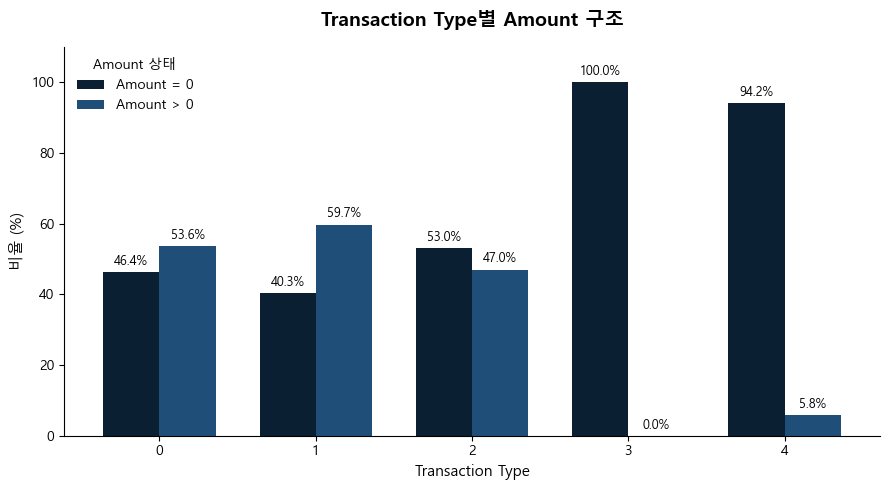

In [15]:
# 25. Transaction Type별 Amount 구조 시각화

import matplotlib.pyplot as plt
import matplotlib as mpl

# 한글 폰트 설정
mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False

# 남색 계열
navy_colors = [
    "#0B1F33",
    "#1F4E79"
]

plot_df = (
    amount_test_df
    .groupby("transaction_type")["amount_status"]
    .value_counts(normalize=True)
    .mul(100)
    .unstack(fill_value=0)
)

# ZERO / POSITIVE 순서 고정
plot_df = plot_df.reindex(
    columns=["ZERO", "POSITIVE"],
    fill_value=0
)

ax = plot_df.plot(
    kind="bar",
    figsize=(9, 5),
    color=navy_colors,
    width=0.72
)

ax.set_title(
    "Transaction Type별 Amount 구조",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Transaction Type", fontsize=11)
ax.set_ylabel("비율 (%)", fontsize=11)

ax.set_ylim(0, 110)

ax.legend(
    ["Amount = 0", "Amount > 0"],
    title="Amount 상태",
    frameon=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

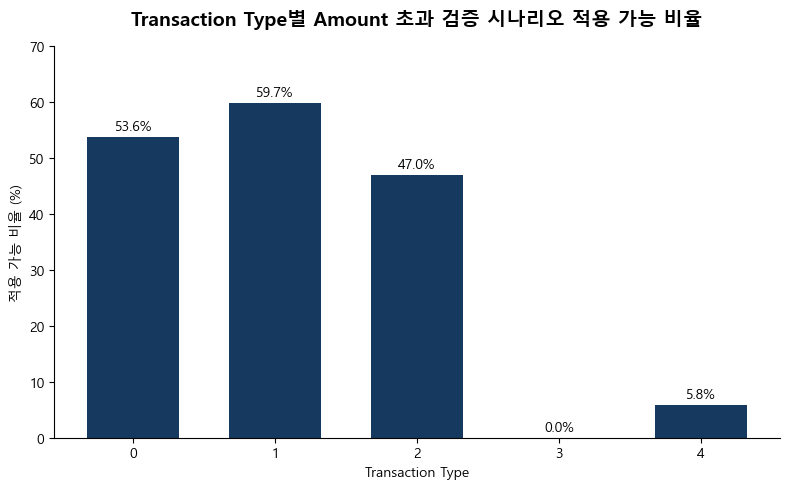

In [16]:
# 26. Transaction Type별 Amount 초과 시나리오 구성 가능 비율

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False

amount_applicable = (
    amount_test_df
    .assign(
        amount_exceeded_applicable=
        amount_test_df["amount_status"].eq("POSITIVE")
    )
    .groupby("transaction_type")["amount_exceeded_applicable"]
    .mean()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    amount_applicable.index.astype(str),
    amount_applicable.values,
    color="#163A5F",
    width=0.65
)

ax.set_title(
    "Transaction Type별 Amount 초과 검증 시나리오 적용 가능 비율",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Transaction Type")
ax.set_ylabel("적용 가능 비율 (%)")
ax.set_ylim(0, 70)

ax.bar_label(
    bars,
    labels=[f"{v:.1f}%" for v in amount_applicable.values],
    padding=3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Transaction Type별 Amount 검증 적용 가능성

실제 Ethereum Requested Transaction을 기준으로 `requested_amount > 0`인 거래의 비율을 확인한 결과, Transaction Type별로 뚜렷한 차이가 나타났다.

- Type 0: 53.6%
- Type 1: 59.7%
- Type 2: 47.0%
- Type 3: 0.0%
- Type 4: 5.8%

특히 Type 3은 모든 거래의 Amount가 0이었으며, Type 4 역시 대부분이 0 Amount 거래였다.

따라서 `AMOUNT_EXCEEDED` Fixture를 전체 Transaction에 일괄적으로 구성하는 것은 적절하지 않다. Amount 초과 검증 시나리오는 실제 요청금액이 0보다 큰 거래에 한해 구성해야 한다.

이는 FPG가 모든 Transaction에 동일한 검증 조건을 기계적으로 적용하는 것이 아니라, **실제 Transaction 구조에 따라 적용 가능한 Approval Rule을 구분해야 함**을 의미한다.

### Transaction Type과 Amount 구조의 관계

카이제곱 독립성 검정 결과, Transaction Type과 Amount 존재 여부(`ZERO / POSITIVE`) 사이에는 통계적으로 유의한 관계가 확인되었다.

- χ²(4) = 12,024.28
- p < 0.001
- Cramér's V = 0.4047

따라서 Transaction Type별 Amount 구조가 동일하다는 귀무가설을 기각한다.

효과크기 역시 작지 않아, 단순히 표본 수가 많아 발생한 통계적 유의성만으로 보기 어렵다. 특히 Type 3과 Type 4에서 0 Amount 거래가 집중된 구조가 전체 차이에 크게 기여한다.

따라서 FPG의 Amount 기반 Approval 검증은 모든 Transaction Type에 동일한 방식으로 적용하기보다, 실제 요청금액이 존재하는 거래를 기준으로 조건부 적용하는 것이 적절하다.

전체 검정에서 유의한 차이가 확인되었으므로, 어떤 Transaction Type 간 차이가 존재하는지 Pairwise 사후검정을 수행한다.

In [17]:
# 26. Transaction Type별 Amount 구조 Pairwise 사후검정

from itertools import combinations
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

pairwise_results = []

transaction_types = sorted(
    amount_test_df["transaction_type"].unique()
)

for type_a, type_b in combinations(transaction_types, 2):

    pair_df = amount_test_df[
        amount_test_df["transaction_type"].isin([type_a, type_b])
    ]

    table = pd.crosstab(
        pair_df["transaction_type"],
        pair_df["amount_status"]
    )

    chi2, p_value, _, _ = chi2_contingency(
        table,
        correction=False
    )

    n = table.to_numpy().sum()

    # 2×2에서는 Cramér's V = Phi
    effect_size = np.sqrt(chi2 / n)

    positive_a = (
        pair_df[
            pair_df["transaction_type"] == type_a
        ]["amount_status"]
        .eq("POSITIVE")
        .mean()
    )

    positive_b = (
        pair_df[
            pair_df["transaction_type"] == type_b
        ]["amount_status"]
        .eq("POSITIVE")
        .mean()
    )

    pairwise_results.append({
        "type_a": type_a,
        "type_b": type_b,
        "positive_pct_a": positive_a * 100,
        "positive_pct_b": positive_b * 100,
        "difference_pp": (positive_a - positive_b) * 100,
        "chi_square": chi2,
        "p_value": p_value,
        "effect_size_phi": effect_size
    })

pairwise_df = pd.DataFrame(pairwise_results)

# Holm 다중비교 보정
reject, p_adjusted, _, _ = multipletests(
    pairwise_df["p_value"],
    method="holm"
)

pairwise_df["p_holm"] = p_adjusted
pairwise_df["significant"] = reject

pairwise_df[
    [
        "positive_pct_a",
        "positive_pct_b",
        "difference_pp",
        "effect_size_phi",
        "p_value",
        "p_holm"
    ]
] = pairwise_df[
    [
        "positive_pct_a",
        "positive_pct_b",
        "difference_pp",
        "effect_size_phi",
        "p_value",
        "p_holm"
    ]
].round(4)

display(pairwise_df)

,type_a,type_b,positive_pct_a,positive_pct_b,difference_pp,chi_square,p_value,effect_size_phi,p_holm,significant
0,0,1,53.6375,59.7250,-6.0875,60.370199,0.0,0.0614,0.0,True
1,0,2,53.6375,46.9742,6.6633,119.256815,0.0,0.0491,0.0,True
2,0,3,53.6375,0.0000,53.6375,5863.523785,0.0,0.6054,0.0,True
3,0,4,53.6375,5.8375,47.8000,4374.090166,0.0,0.5229,0.0,True
4,1,2,59.7250,46.9742,12.7508,436.192774,0.0,0.0940,0.0,True
5,1,3,59.7250,0.0000,59.7250,6812.332917,0.0,0.6525,0.0,True
6,1,4,59.7250,5.8375,53.8875,5271.328980,0.0,0.5740,0.0,True
7,2,3,46.9742,0.0000,46.9742,6197.992621,0.0,0.3542,0.0,True
8,2,4,46.9742,5.8375,41.1367,4715.319366,0.0,0.3089,0.0,True
9,3,4,0.0000,5.8375,-5.8375,481.040366,0.0,0.1734,0.0,True


### Pairwise 사후검정 결과

Holm 보정을 적용한 Transaction Type 간 Pairwise 비교에서 모든 조합이 통계적으로 유의하였다(`p < 0.001`).

그러나 표본 수가 크기 때문에 통계적 유의성만으로 차이의 중요도를 판단하지 않고, Phi 효과크기를 함께 확인하였다.

- Type 0 vs 1: φ = 0.061 → 작은 차이
- Type 0 vs 2: φ = 0.049 → 작은 차이
- Type 1 vs 2: φ = 0.094 → 작은 차이
- Type 0 vs 3: φ = 0.605 → 큰 차이
- Type 0 vs 4: φ = 0.523 → 큰 차이
- Type 1 vs 3: φ = 0.653 → 큰 차이
- Type 1 vs 4: φ = 0.574 → 큰 차이
- Type 2 vs 3: φ = 0.354 → 중간 수준의 차이
- Type 2 vs 4: φ = 0.309 → 중간 수준의 차이
- Type 3 vs 4: φ = 0.173 → 작은 차이

따라서 핵심 차이는 Type 0·1·2 내부가 아니라 **Type 0·1·2와 Type 3·4 사이에서 나타난다.**

Type 0·1·2는 양수 ETH Amount를 포함하는 거래가 약 47~60%인 반면, Type 3은 0%, Type 4는 5.8%에 불과하였다.

이는 FPG의 Approval–Requested Transaction 검증에서 `AMOUNT_EXCEEDED` Rule을 Transaction Type 자체만으로 일괄 적용하기보다, **실제 `requested_amount > 0` 여부를 기준으로 적용 가능성을 판단해야 함**을 의미한다.

즉 Transaction Type은 정책 판정 결과가 아니라, 어떤 Approval Rule이 실질적으로 적용 가능한지를 결정하는 보조적인 Runtime Context로 활용한다.

## Approval–Requested Transaction 검증 결과 요약

본 분석에서는 실제 Ethereum Transaction을 Requested Transaction으로 사용하고, 이에 대응하는 Approval Fixture를 구성하여 실행 직전 승인조건 정합성 검증 로직을 평가하였다.

검증 결과는 다음과 같다.

- 전체 Requested Transaction: 73,410건
- PASS: 36,514건
- BLOCK: 36,896건
- Fixture 대비 Decision 일치율: 100%
- 오분류: 0건
- 단일 조건 위반: 29,557건
- 복수 조건 위반: 7,339건

개별 검증 조건은 Asset, Amount, Destination, Period이며, 하나 이상의 적용 가능한 승인조건을 위반하면 `BLOCK`으로 판정하였다.

Contract Creation 거래 46건은 요청 단계에서 일반적인 Destination이 존재하지 않으므로 Destination 검증을 `N/A`로 처리하였다.

In [18]:
# 27. DA-05 핵심 결과 요약표

summary_df = pd.DataFrame({
    "metric": [
        "Total Requested Transactions",
        "PASS",
        "BLOCK",
        "Single Violation",
        "Multiple Violations",
        "Decision Correct",
        "Misclassified"
    ],
    "count": [
        len(match_df),
        (match_df["decision"] == "PASS").sum(),
        (match_df["decision"] == "BLOCK").sum(),
        (match_df["violation_count"] == 1).sum(),
        (match_df["violation_count"] >= 2).sum(),
        match_df["decision_correct"].sum(),
        (~match_df["decision_correct"]).sum()
    ]
})

summary_df["rate_pct"] = (
    summary_df["count"] / len(match_df) * 100
).round(2)

display(summary_df)

,metric,count,rate_pct
0,Total Requested Transactions,73410,100.00
1,PASS,36514,49.74
2,BLOCK,36896,50.26
3,Single Violation,29557,40.26
4,Multiple Violations,7339,10.00
5,Decision Correct,73410,100.00
6,Misclassified,0,0.00


## FPG 설계 결론

DA-05 분석 결과, FPG의 Digital Asset Runtime에서는 사전 Approval 존재 여부만 확인해서는 충분하지 않다.

외부 실행 직전에 실제 Requested Transaction과 Approval 조건을 다시 비교해야 한다.

필수 Runtime 검증 구조는 다음과 같다.

**Approval → Requested Transaction → Field-level Match → PASS / BLOCK**

검증 대상은 다음과 같다.

- Asset
- Amount
- Destination
- Period

각 Rule은 독립된 Boolean 판정값으로 계산하고, 적용 가능한 조건 중 하나라도 위반되면 전체 Transaction을 `BLOCK` 처리한다.

또한 모든 Rule이 모든 Transaction에 동일하게 적용되는 것은 아니다.

특히 실제 Ethereum 데이터에서는 Transaction Type에 따라 Amount 구조가 크게 달랐으며, Type 3은 양수 Amount 거래가 존재하지 않았고 Type 4 역시 5.8%에 불과하였다.

따라서 FPG는 Transaction Type 자체로 거래를 승인하거나 차단하지 않고, Transaction 구조를 Runtime Context로 사용하여 **어떤 Approval Rule이 적용 가능한지 먼저 판단한 뒤 해당 조건을 검증해야 한다.**

즉 핵심 설계는 다음과 같다.

`Rule Applicability → Approval Match → Decision`

이는 단순한 Schema Validation이 아니라, 승인된 조건이 실제 외부 실행 요청까지 유지되는지를 검증하는 Policy Enforcement 단계이다.

## 한계

본 분석의 Approval Fixture는 실제 금융기관의 승인 이력 데이터가 아니라 검증 로직 평가를 위해 구성한 통제 데이터이다.

따라서 Fixture에서 관측된 Asset, Amount, Destination, Period 위반 비율은 실제 Ethereum 거래 또는 금융기관의 승인 위반 발생률로 해석할 수 없다.

실제 데이터에 존재하지 않는 Purpose, 기관 내부 Approval Workflow, Counterparty Allowlist 등의 조건 역시 본 분석에서는 검증하지 않았다.

향후 실제 기관 Approval Log와 Requested Transaction을 연결할 수 있다면 동일한 Match 구조를 실제 운영 데이터에 적용하여 승인조건 이탈률과 Rule별 운영 특성을 검증할 수 있다.

# DA-05 최종 요약

DA-05에서는 실제 Ethereum Transaction 73,410건을 Requested Transaction으로 구성하고 Approval Fixture와 비교하여, 사전 승인조건이 외부 실행 요청 단계까지 유지되는지를 검증하였다.

Asset, Amount, Destination, Period 조건을 Field 단위로 비교한 결과 Fixture에서 정의한 정상 거래 36,514건은 모두 `PASS`, 하나 이상의 승인조건을 위반한 36,896건은 모두 `BLOCK`으로 판정되었다.

Fixture 대비 Decision 일치율은 100%였으며 오분류는 발생하지 않았다.

실제 Transaction 구조 분석에서는 Transaction Type과 Amount 존재 여부 사이에 유의한 관계가 확인되었다.

- χ²(4) = 12,024.28
- p < 0.001
- Cramér's V = 0.4047

사후검정에서는 Type 0·1·2 내부 차이에 비해 Type 3·4와의 차이가 크게 나타났다. 특히 Type 3은 양수 Amount 거래가 없었으며 Type 4 역시 5.8%에 불과하였다.

따라서 FPG는 모든 Transaction에 동일한 Approval Rule을 기계적으로 적용하는 것이 아니라, Transaction 구조를 기반으로 Rule Applicability를 먼저 결정하고 이후 승인조건과 실제 요청을 비교해야 한다.

DA-05의 최종 설계 결론은 다음과 같다.

**Approval → Requested Transaction → Rule Applicability → Field-level Match → PASS / BLOCK**

즉 FPG Digital Asset Runtime은 사전 승인의 존재 여부만 확인하는 것이 아니라, **승인된 조건이 실제 외부 실행 요청에서도 그대로 유지되는지를 실행 직전에 재검증해야 한다.**